In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import date, datetime
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from itertools import product

In [2]:
traffic = pd.read_csv("../data/Full_Dataset_Cycling.csv")

In [3]:
traffic["Start_Time"] = pd.to_datetime(traffic["Start_Time"])
traffic["End_Time"] = pd.to_datetime(traffic["End_Time"])

In [4]:
traffic.head()

,Site_ID,Direction,Modus,Start_Time,End_Time,Count
0,Location_Tag_1,IN,FIETSERS,2019-08-01 00:00:00,2019-08-01 00:15:00,0.0
1,Location_Tag_1,IN,FIETSERS,2019-08-01 00:15:00,2019-08-01 00:30:00,0.0
2,Location_Tag_1,IN,FIETSERS,2019-08-01 00:30:00,2019-08-01 00:45:00,0.0
3,Location_Tag_1,IN,FIETSERS,2019-08-01 00:45:00,2019-08-01 01:00:00,0.0
4,Location_Tag_1,IN,FIETSERS,2019-08-01 01:00:00,2019-08-01 01:15:00,1.0


### Check autocorrelation

In [8]:
traffic["Date"] = traffic["Start_Time"].dt.date
traffic_day = traffic.groupby(["Site_ID", "Date"])["Count"].sum().astype(int).reset_index()
traffic_day_tag1 = traffic_day[traffic_day["Site_ID"] == "Location_Tag_1"]

In [9]:
traffic_day_tag1.head()

,Site_ID,Date,Count
0,Location_Tag_1,2019-08-01,495
1,Location_Tag_1,2019-08-02,364
2,Location_Tag_1,2019-08-03,273
3,Location_Tag_1,2019-08-04,424
4,Location_Tag_1,2019-08-05,455


In [21]:
autocorr = acf(traffic_day_tag1["Count"], nlags=100, fft=True)
lags = pd.DataFrame({"lag": range(len(autocorr)), "autocorr": autocorr})
lags[lags["autocorr"] >= 0.3].sort_values("autocorr", ascending=False)

,lag,autocorr
0,0,1.000000
1,1,0.630550
7,7,0.528169
14,14,0.493177
6,6,0.444870
21,21,0.434380
2,2,0.416309
8,8,0.414530
28,28,0.408838
13,13,0.385110


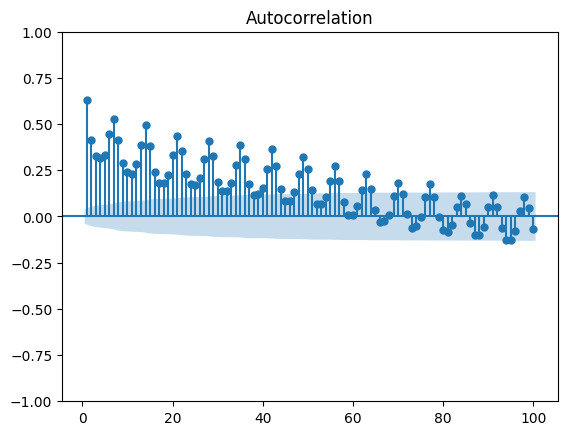

In [11]:
plot_acf(traffic_day_tag1["Count"], lags=100, zero=False);

In [39]:
traffic_train = traffic[(traffic["Start_Time"]>=datetime(2024,7,1)) & (traffic["Start_Time"] <= datetime(2024,12,31))]
traffic_train["Date"] = traffic_train["Start_Time"].dt.date
traffic_train_day = traffic_train.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
traffic_train_day_tag1 = traffic_train_day[traffic_train_day["Site_ID"] == "Location_Tag_1"]

In [40]:
traffic_test = traffic[(traffic["Start_Time"]>=datetime(2025,1,1)) & (traffic["Start_Time"] <= datetime(2025,1,31))]
traffic_test["Date"] = traffic_test["Start_Time"].dt.date
traffic_test_day = traffic_test.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
traffic_test_day_tag1 = traffic_test_day[traffic_test_day["Site_ID"] == "Location_Tag_1"]

In [25]:
traffic_test_day_tag1

,Site_ID,Date,Count
0,Location_Tag_1,2025-01-01,52.0
1,Location_Tag_1,2025-01-02,259.0
2,Location_Tag_1,2025-01-03,152.0
3,Location_Tag_1,2025-01-04,103.0
4,Location_Tag_1,2025-01-05,49.0
5,Location_Tag_1,2025-01-06,299.0
6,Location_Tag_1,2025-01-07,315.0
7,Location_Tag_1,2025-01-08,282.0
8,Location_Tag_1,2025-01-09,169.0
9,Location_Tag_1,2025-01-10,207.0


In [26]:
traffic_train_day_tag1

,Site_ID,Date,Count
0,Location_Tag_1,2024-07-01,563.0
1,Location_Tag_1,2024-07-02,380.0
2,Location_Tag_1,2024-07-03,374.0
3,Location_Tag_1,2024-07-04,483.0
4,Location_Tag_1,2024-07-05,312.0
...,...,...,...
179,Location_Tag_1,2024-12-27,192.0
180,Location_Tag_1,2024-12-28,150.0
181,Location_Tag_1,2024-12-29,122.0
182,Location_Tag_1,2024-12-30,190.0


### SARIMAX model

In [86]:
linear_model = SARIMAX(endog=traffic_train_day_tag1["Count"], exog=None, order=(1,0,1), seasonal_order=(1,0,1,7))

In [87]:
est = linear_model.fit()

/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [88]:
counts_pred = est.forecast(steps=len(traffic_test_day_tag1))

In [89]:
# performance
mae = mean_absolute_error(y_true=traffic_test_day_tag1["Count"], y_pred=counts_pred)
print(f"MAE={mae:.2f}")

MAE=131.67


In [5]:
sites = list(traffic["Site_ID"].unique())

### Loop through all sites one by one

In [51]:
# For testing one site
perf_one = []
for site in sites[:1]:
    try:
        print(f"Fitting the model for site={site}")
        traffic_train = traffic[(traffic["Start_Time"]>=datetime(2025,3,1)) & (traffic["Start_Time"] <= datetime(2026,2,28))]
        traffic_train["Date"] = traffic_train["Start_Time"].dt.date
        traffic_train_day = traffic_train.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
        traffic_train_day_tag1 = traffic_train_day[traffic_train_day["Site_ID"] == site]

        traffic_test = traffic[(traffic["Start_Time"]>=datetime(2026,3,1)) & (traffic["Start_Time"] <= datetime(2026,3,31))]
        traffic_test["Date"] = traffic_test["Start_Time"].dt.date
        traffic_test_day = traffic_test.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
        traffic_test_day_tag1 = traffic_test_day[traffic_test_day["Site_ID"] == site]

        linear_model = SARIMAX(endog=traffic_train_day_tag1["Count"], exog=None, order=(1,0,1), seasonal_order=(1,0,1,7))
        est = linear_model.fit()
        counts_pred = est.forecast(steps=len(traffic_test_day_tag1))

        traffic_test_day_tag1["CountPred"] = counts_pred.values
        perf_one.append(traffic_test_day_tag1.copy(deep=True))

    except:
        print(f"Issue with site={site}")

Fitting the model for site=Location_Tag_1


In [52]:
perf_one = pd.concat(perf_one)
mae = mean_absolute_error(y_true=perf_one["Count"], y_pred=perf_one["CountPred"])
rmse = root_mean_squared_error(y_true=perf_one["Count"], y_pred=perf_one["CountPred"])
print(f"MAE={mae:.2f}, RMSE={rmse:.2f}")

MAE=168.59, RMSE=192.03


In [44]:
traffic_test_day_tag1[["Count", "CountPred"]]

,Count,CountPred
0,502.0,-105.908610
1,408.0,-61.302377
2,372.0,-4.129849
3,289.0,-41.508612
4,216.0,-14.750526
5,377.0,42.056408
6,602.0,-115.462812
7,624.0,-155.096505
8,532.0,-119.106813
9,411.0,-78.324638


In [36]:
traffic_train["Count"].describe()

count    9.554243e+06
mean     2.689770e+00
std      7.840555e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      5.402000e+03
Name: Count, dtype: float64

In [37]:
traffic_test["Count"].describe()

count    775378.000000
mean          1.761052
std           5.622944
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         521.000000
Name: Count, dtype: float64

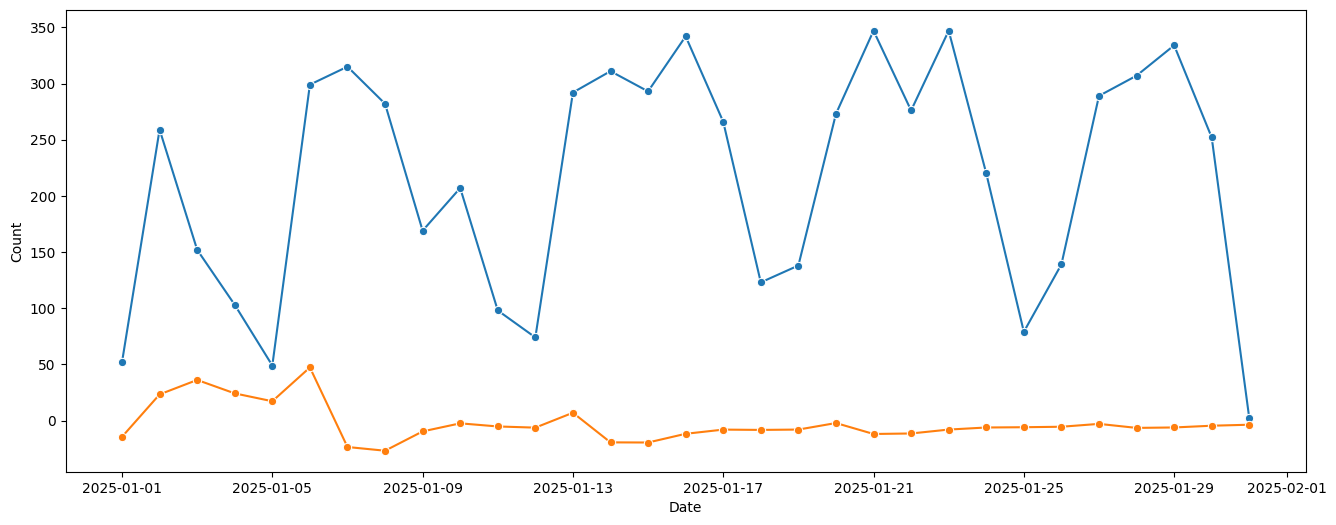

In [38]:
perf_one_site = perf_one[perf_one["Site_ID"] == "Location_Tag_1"]

plt.figure(figsize=(16,6))
sns.lineplot(data=perf_one_site, x="Date", y="Count", errorbar=None, marker="o")
sns.lineplot(data=perf_one_site, x="Date", y="CountPred", errorbar=None, marker="o");

In [166]:
traffic.tail()

,Site_ID,Direction,Modus,Start_Time,End_Time,Count,Date
42789169,Location_Tag_152,OUT,FIETSERS,2026-05-04 03:45:00,2026-05-04 04:00:00,0.0,2026-05-04
42789170,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:00:00,2026-05-04 04:15:00,0.0,2026-05-04
42789171,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:15:00,2026-05-04 04:30:00,0.0,2026-05-04
42789172,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:30:00,2026-05-04 04:45:00,0.0,2026-05-04
42789173,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:45:00,2026-05-04 05:00:00,0.0,2026-05-04


### One site walk forward test

In [284]:
order_p = [1, 2]
order_d = [0]
order_q = [1, 2]

seasonal_order_P = [1, 2]
seasonal_order_D = [0]
seasonal_order_Q = [1, 2]
seasonal_order_s = [7]

In [285]:
hyperparams = [order_p, order_d, order_q, seasonal_order_P, seasonal_order_D, seasonal_order_Q, seasonal_order_s]
hyperparams = list(product(*hyperparams))

In [286]:
len(hyperparams)

16

In [197]:
hyperparams[:2]

[(2, 0, 2, 2, 0, 2, 7), (2, 0, 2, 2, 0, 3, 7)]

In [268]:
hyperparams = [(1,0,1,1,0,1,7)]

In [198]:
test_start_dates = list(pd.date_range(start="2026-04-01", end="2026-04-01", freq="MS"))

In [287]:
test_start_dates

[Timestamp('2026-04-01 00:00:00')]

In [298]:
site = "Location_Tag_11"
perf = []
pred = []
for test_start_date in test_start_dates:
    for hp in hyperparams:
        try:
            print(f"Fitting the model for site={site}")
            train_start_date = test_start_date - pd.Timedelta(days=365)
            train_end_date = test_start_date - pd.Timedelta(days=1)
            traffic_train = traffic[(traffic["Start_Time"]>=train_start_date) & (traffic["Start_Time"] <= train_end_date)]
            traffic_train["Date"] = traffic_train["Start_Time"].dt.date
            traffic_train_day = traffic_train.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
            traffic_train_day_tag1 = traffic_train_day[traffic_train_day["Site_ID"] == site]

            test_end_date = test_start_date + pd.Timedelta(days=30)
            traffic_test = traffic[(traffic["Start_Time"]>=test_start_date) & (traffic["Start_Time"] <= test_end_date)]
            traffic_test["Date"] = traffic_test["Start_Time"].dt.date
            traffic_test_day = traffic_test.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
            traffic_test_day_tag1 = traffic_test_day[traffic_test_day["Site_ID"] == site]
            print(f"train_start_date={train_start_date}, train_end_date={train_end_date}, test_start_date={test_start_date}, test_end_date={test_end_date}")
            print(f"traffic_train_day_tag1.shape={traffic_train_day_tag1.shape}, traffic_test_day_tag1.shape={traffic_test_day_tag1.shape}")

            order = (hp[0], hp[1], hp[2])
            seasonal_order = (hp[3], hp[4], hp[5], hp[6])
            print(f"order={order}, seasonal_order={seasonal_order}")
            
            linear_model = SARIMAX(
                endog=traffic_train_day_tag1["Count"],
                exog=None,
                # simple_differencing=True,
                # enforce_invertibility=False,
                # enforce_stationarity=False,
                order=order,
                seasonal_order=seasonal_order)
            
            # print(linear_model.param_names)
            # start_params = [0.5] * (len(linear_model.param_names)-1) + [10000]
            est = linear_model.fit(maxiter=300)
            counts_pred = est.forecast(steps=len(traffic_test_day_tag1))

            traffic_test_day_tag1["CountPred"] = counts_pred.values
            traffic_test_day_tag1["Order"] = [order] * len(traffic_test_day_tag1)
            traffic_test_day_tag1["SeasonalOrder"] = [seasonal_order] * len(traffic_test_day_tag1)

            mae = mean_absolute_error(y_true=traffic_test_day_tag1["Count"], y_pred=traffic_test_day_tag1["CountPred"])
            rmse = root_mean_squared_error(y_true=traffic_test_day_tag1["Count"], y_pred=traffic_test_day_tag1["CountPred"])

            perf.append({"test_start_date": test_start_date, "order": order, "seasonal_order": seasonal_order, "MAE": mae, "RMSE": rmse})
            pred.append(traffic_test_day_tag1.copy(deep=True))

        except:
            print(f"Issue with site={site}")

Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(1, 0, 1), seasonal_order=(1, 0, 1, 7)
Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(1, 0, 1), seasonal_order=(1, 0, 2, 7)
Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(1, 0, 1), seasonal_order=(2, 0, 1, 7)
Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00

/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(2, 0, 1), seasonal_order=(1, 0, 2, 7)


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(2, 0, 1), seasonal_order=(2, 0, 1, 7)


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(2, 0, 1), seasonal_order=(2, 0, 2, 7)


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(2, 0, 2), seasonal_order=(1, 0, 1, 7)
Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(2, 0, 2), seasonal_order=(1, 0, 2, 7)
Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00:00, train_end_date=2026-03-31 00:00:00, test_start_date=2026-04-01 00:00:00, test_end_date=2026-05-01 00:00:00
traffic_train_day_tag1.shape=(365, 3), traffic_test_day_tag1.shape=(31, 3)
order=(2, 0, 2), seasonal_order=(2, 0, 1, 7)
Fitting the model for site=Location_Tag_11
train_start_date=2025-04-01 00:00

In [299]:
perf = pd.DataFrame(perf)

In [300]:
pred = pd.concat(pred)

In [301]:
pred

,Site_ID,Date,Count,CountPred,Order,SeasonalOrder
372,Location_Tag_11,2026-04-01,782.0,211.151238,"(1, 0, 1)","(1, 0, 1, 7)"
373,Location_Tag_11,2026-04-02,642.0,263.822321,"(1, 0, 1)","(1, 0, 1, 7)"
374,Location_Tag_11,2026-04-03,721.0,325.136744,"(1, 0, 1)","(1, 0, 1, 7)"
375,Location_Tag_11,2026-04-04,439.0,139.586719,"(1, 0, 1)","(1, 0, 1, 7)"
376,Location_Tag_11,2026-04-05,325.0,131.747464,"(1, 0, 1)","(1, 0, 1, 7)"
...,...,...,...,...,...,...
398,Location_Tag_11,2026-04-27,1063.0,566.973303,"(2, 0, 2)","(2, 0, 2, 7)"
399,Location_Tag_11,2026-04-28,1088.0,558.736564,"(2, 0, 2)","(2, 0, 2, 7)"
400,Location_Tag_11,2026-04-29,1080.0,584.344232,"(2, 0, 2)","(2, 0, 2, 7)"
401,Location_Tag_11,2026-04-30,1112.0,573.607353,"(2, 0, 2)","(2, 0, 2, 7)"


In [302]:
perf_1011017 = perf[(perf["order"] == (1,0,1)) & (perf["seasonal_order"] == (1,0,1,7))]

In [306]:
perf_best_hp = perf.groupby("test_start_date")["MAE"].min().reset_index()
perf_best_hp

,test_start_date,MAE
0,2026-04-01,263.105116


In [304]:
perf

,test_start_date,order,seasonal_order,MAE,RMSE
0,2026-04-01,"(1, 0, 1)","(1, 0, 1, 7)",304.589898,349.884411
1,2026-04-01,"(1, 0, 1)","(1, 0, 2, 7)",272.015690,320.598014
2,2026-04-01,"(1, 0, 1)","(2, 0, 1, 7)",303.491638,348.808220
3,2026-04-01,"(1, 0, 1)","(2, 0, 2, 7)",301.693076,348.213654
4,2026-04-01,"(1, 0, 2)","(1, 0, 1, 7)",309.563789,353.218443
5,2026-04-01,"(1, 0, 2)","(1, 0, 2, 7)",281.864330,326.705719
6,2026-04-01,"(1, 0, 2)","(2, 0, 1, 7)",283.747153,328.546918
7,2026-04-01,"(1, 0, 2)","(2, 0, 2, 7)",271.910300,317.248165
8,2026-04-01,"(2, 0, 1)","(1, 0, 1, 7)",307.907123,354.413135
9,2026-04-01,"(2, 0, 1)","(1, 0, 2, 7)",266.917408,319.794899


### Predictions visualization

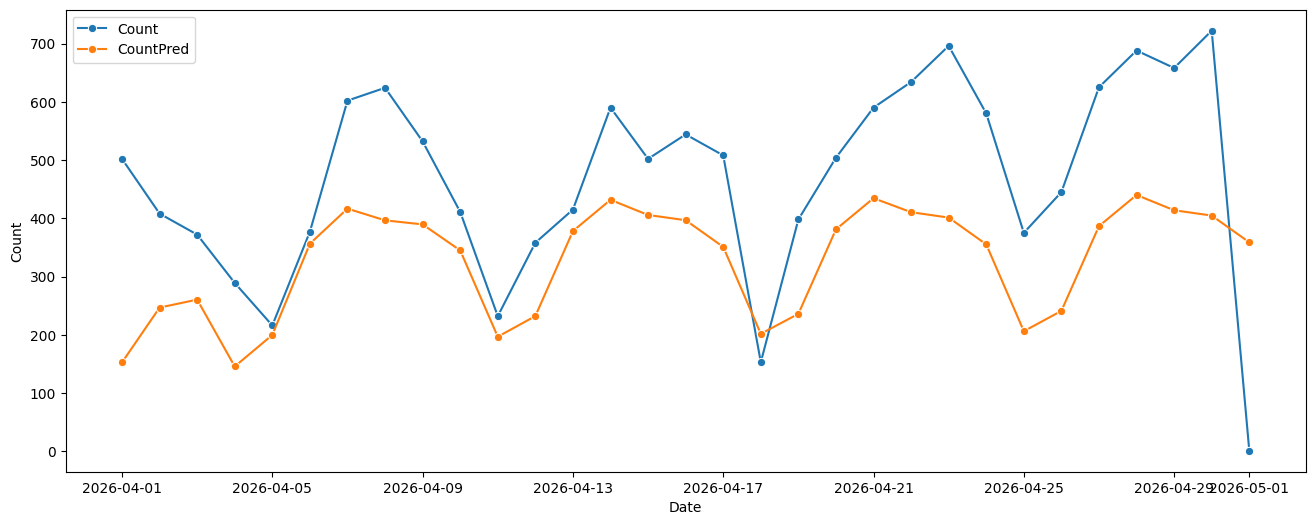

In [297]:
pred_best_hp = pred[(pred["Order"] == (2,0,1)) & (pred["SeasonalOrder"] == (2,0,2,7))]

plt.figure(figsize=(16,6))
sns.lineplot(data=pred_best_hp, x="Date", y="Count", marker="o", label="Count");
sns.lineplot(data=pred_best_hp, x="Date", y="CountPred", marker="o", label="CountPred");

plt.legend(title="");

In [294]:
perf_best_hp

,test_start_date,MAE
0,2026-04-01,167.484499


In [262]:
perf_1011017

,test_start_date,order,seasonal_order,MAE,RMSE
0,2026-04-01,"(1, 0, 1)","(1, 0, 1, 7)",207.454386,225.283465


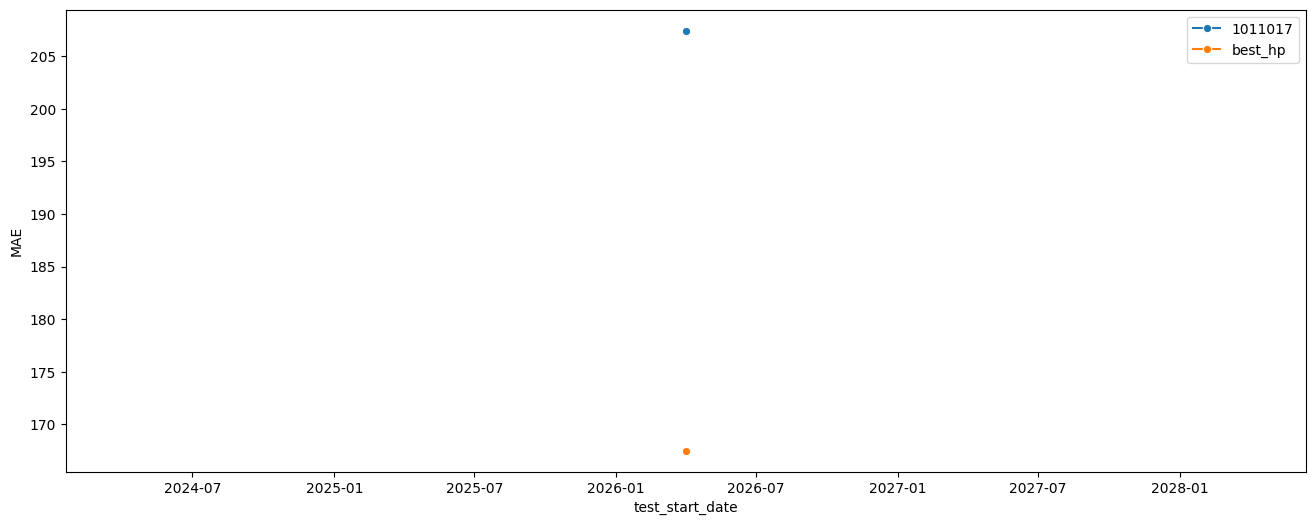

In [263]:
plt.figure(figsize=(16,6))
sns.lineplot(data=perf_1011017, x="test_start_date", y="MAE", marker="o", label="1011017");
sns.lineplot(data=perf_best_hp, x="test_start_date", y="MAE", marker="o", label="best_hp");

plt.legend(title="");

In [14]:
perf = []
for site in sites:
    try:
        print(f"Fitting the model for site={site}")
        traffic_train = traffic[(traffic["Start_Time"]>=datetime(2025,1,1)) & (traffic["Start_Time"] <= datetime(2025,12,31))]
        traffic_train["Date"] = traffic_train["Start_Time"].dt.date
        traffic_train_day = traffic_train.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
        traffic_train_day_tag1 = traffic_train_day[traffic_train_day["Site_ID"] == site]

        traffic_test = traffic[(traffic["Start_Time"]>=datetime(2026,4,1)) & (traffic["Start_Time"] <= datetime(2026,4,30))]
        traffic_test["Date"] = traffic_test["Start_Time"].dt.date
        traffic_test_day = traffic_test.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
        traffic_test_day_tag1 = traffic_test_day[traffic_test_day["Site_ID"] == site]

        linear_model = SARIMAX(endog=traffic_train_day_tag1["Count"], exog=None, order=(2,0,1), seasonal_order=(2,0,1,7))
        est = linear_model.fit(maxiter=300)
        counts_pred = est.forecast(steps=len(traffic_test_day_tag1))

        traffic_test_day_tag1["CountPred"] = counts_pred.values
        perf.append(traffic_test_day_tag1.copy(deep=True))

    except:
        print(f"Issue with site={site}")

Fitting the model for site=Location_Tag_1


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_2


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_3


...

/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_150
Fitting the model for site=Location_Tag_151


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitting the model for site=Location_Tag_152


/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wingong/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [15]:
perf = pd.concat(perf)

In [16]:
mae = mean_absolute_error(y_true=perf["Count"], y_pred=perf["CountPred"])
rmse = root_mean_squared_error(y_true=perf["Count"], y_pred=perf["CountPred"])
print(f"MAE={mae:.2f}, RMSE={rmse:.2f}")

MAE=376.26, RMSE=629.09


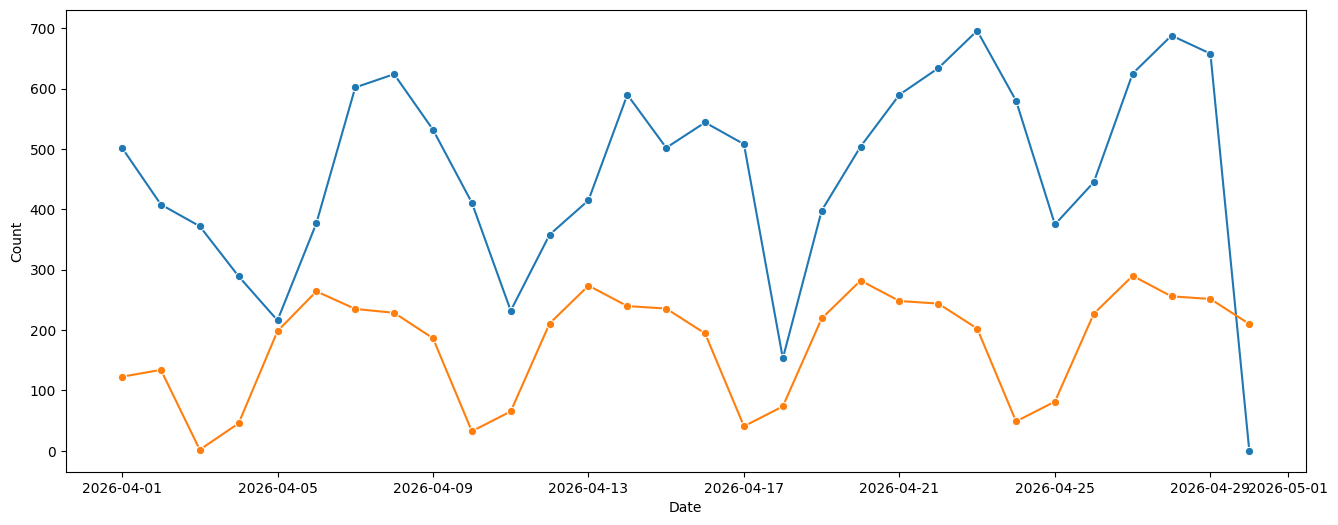

In [17]:
perf_one_site = perf[perf["Site_ID"] == "Location_Tag_1"]

plt.figure(figsize=(16,6))
sns.lineplot(data=perf_one_site, x="Date", y="Count", errorbar=None, marker="o")
sns.lineplot(data=perf_one_site, x="Date", y="CountPred", errorbar=None, marker="o");

In [20]:
traffic["Date"] = pd.to_datetime(traffic["Start_Time"])

In [23]:
traffic["Month"] = pd.to_datetime(traffic["Start_Time"]).dt.month

In [29]:
traffic["Year"] = pd.to_datetime(traffic["Start_Time"]).dt.year

In [32]:
traffic[traffic["Year"] == 2024].groupby("Month")["Count"].sum()

Month
1     1397946.0
2     1606722.0
3     2138682.0
4     1951952.0
5     2427529.0
6     2565870.0
7     2467646.0
8     2785589.0
9     2640017.0
10    2452340.0
11    1823988.0
12    1472360.0
Name: Count, dtype: float64

In [18]:
traffic_train = traffic[(traffic["Start_Time"]>=datetime(2025,4,1)) & (traffic["Start_Time"] <= datetime(2026,3,31))]
traffic_train["Date"] = traffic_train["Start_Time"].dt.date
traffic_train_day = traffic_train.groupby(["Site_ID", "Date"])["Count"].sum().reset_index()
traffic_train_day_tag1 = traffic_train_day[traffic_train_day["Site_ID"] == "Location_Tag_1"]

autocorr = acf(traffic_train_day_tag1["Count"], nlags=100, fft=True)
lags = pd.DataFrame({"lag": range(len(autocorr)), "autocorr": autocorr})
lags[lags["autocorr"] >= 0.4].sort_values("autocorr", ascending=False)

,lag,autocorr
0,0,1.000000
1,1,0.643989
7,7,0.566684
14,14,0.499969
42,42,0.495579
6,6,0.458056
21,21,0.457944
35,35,0.440419
28,28,0.417856


In [28]:
traffic_train_day_tag1

,Site_ID,Date,Count
0,Location_Tag_1,2025-04-01,591.0
1,Location_Tag_1,2025-04-02,528.0
2,Location_Tag_1,2025-04-03,649.0
3,Location_Tag_1,2025-04-04,562.0
4,Location_Tag_1,2025-04-05,336.0
...,...,...,...
360,Location_Tag_1,2026-03-27,382.0
361,Location_Tag_1,2026-03-28,259.0
362,Location_Tag_1,2026-03-29,267.0
363,Location_Tag_1,2026-03-30,339.0


In [50]:
pd.DataFrame({"Site_ID": "L1", "Date":traffic_test_day_tag1["Date"]})

,Site_ID,Date
0,L1,2025-01-01
1,L1,2025-01-02
2,L1,2025-01-03
3,L1,2025-01-04
4,L1,2025-01-05
5,L1,2025-01-06
6,L1,2025-01-07
7,L1,2025-01-08
8,L1,2025-01-09
9,L1,2025-01-10


In [69]:
traffic_train_day_tag1["CountMinusOne"] = traffic_test_day_tag1["Count"].shift(1)
traffic_train_day_tag1["CountMinusTwo"] = traffic_test_day_tag1["Count"].shift(2)

In [ ]:
traffic_train_day_tag1 = traffic_train_day_tag1.dropna()

In [71]:
traffic_train_day_tag1

,Site_ID,Date,Count,CountMinusOne,CountMinusTwo
2,Location_Tag_1,2022-01-03,161.0,259.0,52.0
3,Location_Tag_1,2022-01-04,149.0,152.0,259.0
4,Location_Tag_1,2022-01-05,192.0,103.0,152.0
5,Location_Tag_1,2022-01-06,248.0,49.0,103.0
6,Location_Tag_1,2022-01-07,144.0,299.0,49.0
...,...,...,...,...,...
176,Location_Tag_1,2022-06-26,462.0,656.0,651.0
177,Location_Tag_1,2022-06-27,467.0,353.0,656.0
178,Location_Tag_1,2022-06-28,666.0,476.0,353.0
179,Location_Tag_1,2022-06-29,695.0,408.0,476.0
